# Variables climáticas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import geopandas as gpd
from scipy import stats

In [18]:
df = pd.read_csv(r"C:\Users\Hp\DENGUE\DATOS\data_clima.csv", encoding='latin_1', low_memory=False)

df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14417 entries, 0 to 14416
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Codigo                    14417 non-null  int64         
 1   Nombre                    14417 non-null  object        
 2   Fecha                     14417 non-null  datetime64[ns]
 3   Humedad relativa maxima   2418 non-null   float64       
 4   Humendad relativa minima  2418 non-null   float64       
 5   Precipitacion             12411 non-null  float64       
 6   Temperatura maxima        3677 non-null   float64       
 7   Temperatura minima        4520 non-null   float64       
 8   Latitud                   14417 non-null  float64       
 9   Longitud                  14417 non-null  float64       
 10  Altitud                   14417 non-null  int64         
dtypes: datetime64[ns](1), float64(7), int64(2), object(1)
memory usage: 1.2+ MB


## Estaciones

In [19]:
df['Nombre'].unique()

array(['NORMAL MANATI', 'AEROPUERTO E. CORTISSOZ', 'BARRANQUILLA SEDE',
       'JUAN DE ACOSTA', 'MONTEBELLO', 'CANDELARIA', 'LEÑA',
       'LOMA GRANDE', 'CASA DE BOMBAS', 'CAMPO DE LA CRUZ', 'HIBACHARO',
       'PIOJO', 'CAMPANOS LOS', 'PINTADA LA', 'POLONUEVO'], dtype=object)

In [22]:
print("Fechas")
print(f"Fecha mínima {df['Fecha'].min()}")
print(f'Fecha máxima {df['Fecha'].max()}')

Fechas
Fecha mínima 2016-12-31 00:00:00
Fecha máxima 2024-01-01 00:00:00


In [26]:
gdf = gpd.read_file(r"C:\Users\Hp\DENGUE\DATOS\atlantico_municipios.shp", encoding='utf_8')
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   dpto_ccdgo  23 non-null     object  
 1   mpio_ccdgo  23 non-null     object  
 2   mpio_cdpmp  23 non-null     object  
 3   dpto_cnmbr  23 non-null     object  
 4   mpio_cnmbr  23 non-null     object  
 5   mpio_crslc  23 non-null     object  
 6   mpio_tipo   23 non-null     object  
 7   mpio_narea  23 non-null     float64 
 8   mpio_nano   23 non-null     int32   
 9   shape_Leng  23 non-null     float64 
 10  shape_Area  23 non-null     float64 
 11  geometry    23 non-null     geometry
dtypes: float64(3), geometry(1), int32(1), object(7)
memory usage: 2.2+ KB


C:\Users\Hp\AppData\Local\Temp\ipykernel_14924\3542819561.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_puntos['zona'] = gdf_puntos.geometry.buffer(0.05)  # Radio en grados (aprox. 1 km)


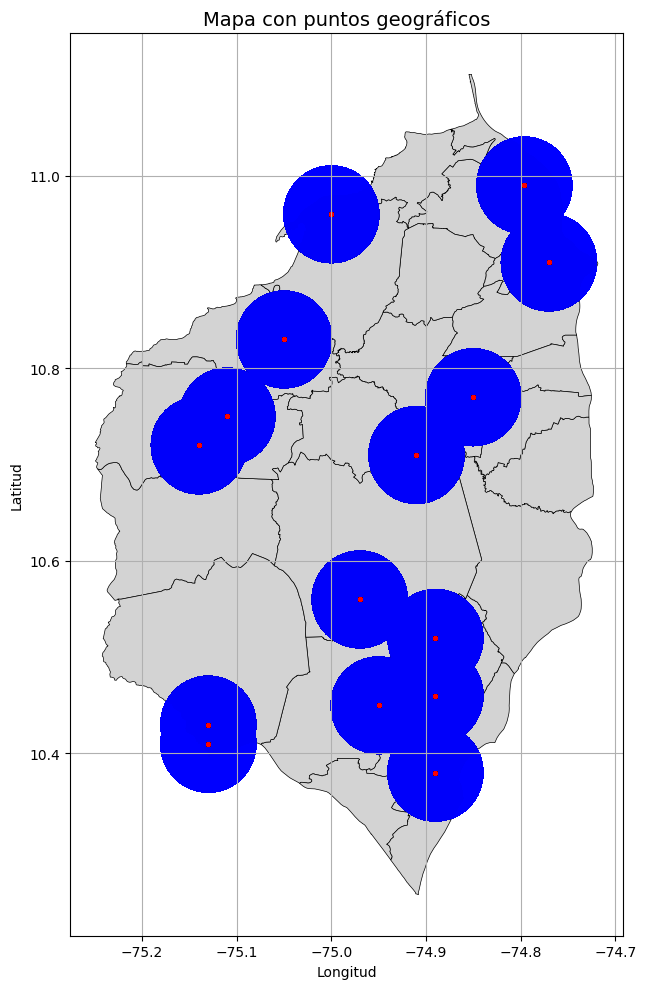

In [32]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import Point
from shapely.geometry import Polygon
import geopandas as gpd


# 1. Convertir df a GeoDataFrame usando Latitud y Longitud
df['geometry'] = [Point(xy) for xy in zip(df['Longitud'], df['Latitud'])]
gdf_puntos = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')  # CRS geográfico estándar
gdf_puntos['zona'] = gdf_puntos.geometry.buffer(0.05)  # Radio en grados (aprox. 1 km)

# 2. Asegurar que el shapefile también esté en EPSG:4326
gdf = gdf.to_crs('EPSG:4326')

# 3. Graficar mapa base y puntos
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
gdf_puntos['zona'].plot(ax=ax, color='blue', alpha=0.2, edgecolor='blue')  # Círculos
gdf_puntos.plot(ax=ax, color='red', markersize=5, alpha=0.6)

# 4. Título y etiquetas en español
ax.set_title('Mapa con puntos geográficos', fontsize=14)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.grid(True)
plt.tight_layout()
plt.show()

## Clima

In [33]:
df['Humedad relativa maxima'].describe()

count    2418.000000
mean       96.211332
std         2.165190
min        87.000000
25%        95.000000
50%        97.000000
75%        98.000000
max       100.000000
Name: Humedad relativa maxima, dtype: float64

<Axes: >

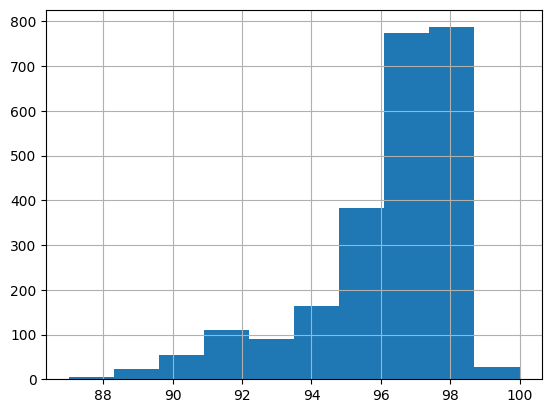

In [36]:
df['Humedad relativa maxima'].hist()

In [37]:
df['Precipitacion'].describe()

count    12411.000000
mean         9.240956
std         16.039534
min          0.000000
25%          0.000000
50%          1.600000
75%         12.000000
max        140.000000
Name: Precipitacion, dtype: float64

<Axes: >

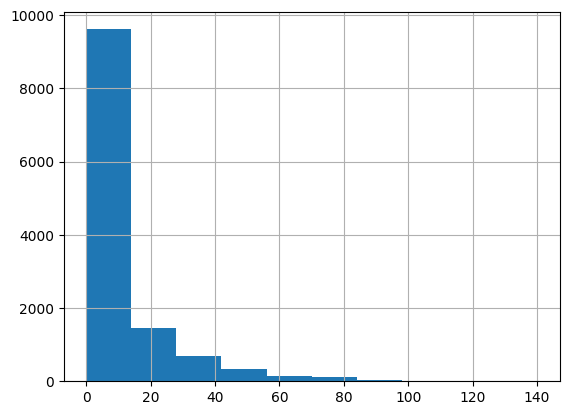

In [41]:
df['Precipitacion'].hist()

In [42]:
df['Temperatura maxima'].describe()

count    3677.000000
mean       33.738863
std         1.433534
min        26.400000
25%        33.000000
50%        34.000000
75%        34.600000
max        39.000000
Name: Temperatura maxima, dtype: float64

<Axes: >

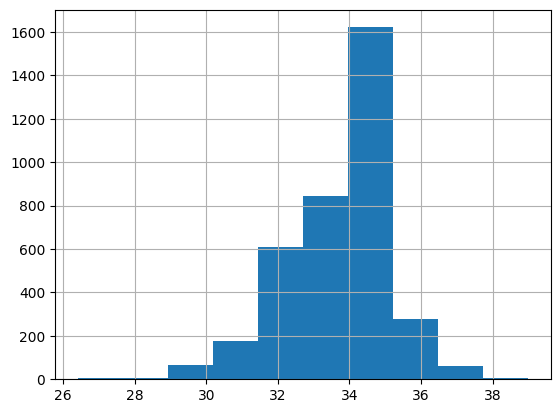

In [45]:
df['Temperatura maxima'].hist()